# Fichier principal
# fusion de tous les fichiers.ipynb avec le fichier application_train.ipynb

In [1]:
import os
import re
import numpy as np
import pandas as pd
import gc
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, precision_recall_curve, auc, make_scorer, average_precision_score, make_scorer
from sklearn.model_selection import KFold, train_test_split, StratifiedKFold, cross_val_score, cross_val_predict,cross_validate, TunedThresholdClassifierCV
from sklearn.utils.class_weight import compute_class_weight
from imblearn.over_sampling import SMOTE

import catboost
import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostClassifier, cv, Pool
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

import matplotlib.pyplot as plt
import seaborn as sns
import pickle

import mlflow
import mlflow.sklearn
import mlflow.xgboost
import mlflow.lightgbm
import mlflow.catboost
import optuna
import shap
from mlflow.models.signature import infer_signature


print(" Imports terminés")

c:\Users\chris\Initiez_vous_au_ML_Ops\venv312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


 Imports terminés


In [2]:
print(catboost.__version__) # pour vérifier si __sklearn_tags__ s'implemente

1.2.10


# optimisation de la RAM

In [3]:
def reduce_mem_usage(df, verbose=True):
    """Réduit l'usage mémoire en convertissant les types de données"""
    start_mem = df.memory_usage().sum() / 1024**2
    
    for col in df.columns:
        col_type = df[col].dtype
        
        if col_type != object:
            c_min = df[col].min()
            c_max = df[col].max()
            
            if str(col_type)[:3] == 'int':
                if c_min > np.iinfo(np.int8).min and c_max < np.iinfo(np.int8).max:
                    df[col] = df[col].astype(np.int8)
                elif c_min > np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max:
                    df[col] = df[col].astype(np.int16)
                elif c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
                    df[col] = df[col].astype(np.int32)
            else:
                if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
                    df[col] = df[col].astype(np.float32)
    
    end_mem = df.memory_usage().sum() / 1024**2
    if verbose:
        print(f'Mémoire réduite de {start_mem:.2f} MB à {end_mem:.2f} MB ({100 * (start_mem - end_mem) / start_mem:.1f}% reduction)')
    
    return df

# bureau et bureau_balance

In [4]:
with open("bureau_agg.pkl", "rb") as f:
    bureau_agg = pickle.load(f)

gc.collect()

100

# Credit CARD 

In [5]:
with open("credit_card_client.pkl", "rb") as f:
    credit_card_client = pickle.load(f)

gc.collect()

0

# INSTALLMENTS

In [6]:
with open("installments_agg.pkl", "rb") as f: 
    installments_agg = pickle.load(f)

gc.collect()

0

# Previous Application 

In [7]:
with open('prev_agg.pkl', 'rb') as f:
    prev_agg = pickle.load(f)
    
gc.collect()

0

# POS_CASH

In [8]:
with open('pos_agg.pkl', 'rb') as f:
    pos_agg = pickle.load(f)

gc.collect()

0

In [9]:
# application_train et application_test

In [10]:
with open("app_train_domain.pkl", "rb") as f:
    app_train_domain = pickle.load(f)

with open("app_test_domain.pkl", "rb") as f:
    app_test_domain = pickle.load(f)

gc.collect()    

0

In [11]:
# Fusion progressive de toutes les tables sur SK_ID_CURR

In [12]:
print("Début de la fusion...")

# app_train_domain, variable du kernel kaggle
train = app_train_domain.copy()

print(f"Train initial: {train.shape}")

# Fusion avec Bureau
train = train.merge(bureau_agg, on='SK_ID_CURR', how='left')

print(f"Après bureau: {train.shape}")

# Fusion avec Credit Card 
train = train.merge(credit_card_client, on='SK_ID_CURR', how='left')

print(f"Après credit: {train.shape}")



# Fusion avec Installments:
## Cas particulier: Charger la correspondance SK_ID_PREV avec SK_ID_CURR de previous_application
## chargement des données depuis la racine du projet
data_dir = 'data/' 
prev_link = pd.read_csv(data_dir + 'previous_application.csv',
                        usecols=['SK_ID_CURR', 'SK_ID_PREV'])
prev_link = reduce_mem_usage(prev_link)

## Fusionner installments_agg avec la correspondance
installments_with_curr = prev_link.merge(
    installments_agg,
    on='SK_ID_PREV',
    how='left'
)
## Agréger au niveau client (SK_ID_CURR)
installments_agg = (installments_with_curr
                     .drop('SK_ID_PREV', axis=1)
                     .groupby('SK_ID_CURR')
                     .agg(['mean', 'max', 'min', 'sum']))

installments_agg.columns = ['INSTAL_' + '_'.join(col).upper()
                              for col in installments_agg.columns]
installments_agg.reset_index(inplace=True)

print(f"\n installments_agg shape: {installments_agg.shape}")

## Fusion avec train
train = train.merge(installments_agg, on='SK_ID_CURR', how='left')

print(f"Après installments: {train.shape}")



# Fusion avec Previous Application
train = train.merge(prev_agg, on='SK_ID_CURR', how='left')

print(f"Après previous: {train.shape}")

# Fusion avec POS_CASH
train = train.merge(pos_agg, on='SK_ID_CURR', how='left')

print(f"Après POS_CASH: {train.shape}")


print("\n Toutes les fusions terminées ")
print(f"\n Shape final TRAIN: {train.shape}")

Début de la fusion...
Train initial: (307511, 232)
Après bureau: (307511, 316)
Après credit: (307511, 425)
Mémoire réduite de 25.49 MB à 12.74 MB (50.0% reduction)

 installments_agg shape: (338857, 89)
Après installments: (307511, 513)
Après previous: (307511, 727)
Après POS_CASH: (307511, 749)

 Toutes les fusions terminées 

 Shape final TRAIN: (307511, 749)


# Correlation entre features numériques
# Les modèles LightGBM, XGBoost, CatBoost gèrent très bien les redondances comme les corrélations

# vérification de y

In [13]:
y=train['TARGET']
print("\n1️ Vérification de y (TARGET):")
print(f"   Type: {y.dtype}")
print(f"   Valeurs uniques: {y.unique()}")
print(f"   Distribution: \n{y.value_counts()}")

# si y est déjà en 0/1, pas besoin d'encoder
if set(y.unique()) == {0, 1}:
    print("    y est déjà encodé en 0/1")
else:
    print("    y n'est pas en 0/1, encodage nécessaire")


1️ Vérification de y (TARGET):
   Type: int64
   Valeurs uniques: [1 0]
   Distribution: 
TARGET
0    282686
1     24825
Name: count, dtype: int64
    y est déjà encodé en 0/1


# mapping cible de y pour s'assurer que  0 et 1 sont bien interprétés

In [14]:
mapping_cible = {0: "rembourse le crédit", 1: "ne rembourse pas le crédit"}
y = y.map(mapping_cible)

# Préparer et séparer features X et target y

In [15]:
# on garde les lignes de app_train_domain quand y(target) existe en 0 ou 1
train_clean = app_train_domain.dropna(subset=['TARGET']).copy() 

# On enlève la colonne y (target) de X et l'ID qui n'est pas une feature pour le modèle
X = train_clean.drop(columns=['TARGET', 'SK_ID_CURR']).fillna(-999)
y = train_clean['TARGET'].astype(int)  # pour avoir 0 et 1 en nombre entier

# Test : utiliser app_test_domain
X_test = app_test_domain.drop(columns=['SK_ID_CURR'], errors='ignore').fillna(-999)

# Aligner les colonnes
X, X_test = X.align(X_test, join='inner', axis=1)

print(f"\n Préparation OK:")
print(f"   X:      {X.shape}")
print(f"   y:      {y.shape}  |  valeurs: {sorted(y.unique())}")
print(f"   X_test: {X_test.shape}")
print(f"   NaN dans y: {y.isnull().sum()}")
print(f"   Distribution y: {y.value_counts().to_dict()}")

# Split stratifié
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y # stratification pour maintenir la même proportion de classes dans les splits
)

print(f"\n Split OK:")
print(f"   X_train: {X_train.shape}  |  défauts: {y_train.mean():.2%}")  # tx défaut paiement dans le train
print(f"   X_val:   {X_val.shape}    |  défauts: {y_val.mean():.2%}")
print(f"   X_test:  {X_test.shape}")


print("\n Données prêtes pour la modélisation")


 Préparation OK:
   X:      (307511, 226)
   y:      (307511,)  |  valeurs: [np.int64(0), np.int64(1)]
   X_test: (48744, 226)
   NaN dans y: 0
   Distribution y: {0: 282686, 1: 24825}

 Split OK:
   X_train: (246008, 226)  |  défauts: 8.07%
   X_val:   (61503, 226)    |  défauts: 8.07%
   X_test:  (48744, 226)

 Données prêtes pour la modélisation


# création de l'expérience mlflow

In [16]:
mlflow.set_experiment("Home_Credit_Default_Risk")


<Experiment: artifact_location='mlruns/1', creation_time=None, experiment_id='1', last_update_time=None, lifecycle_stage='active', name='Home_Credit_Default_Risk', tags={'mlflow.experimentKind': 'custom_model_development'}>

# Class weight (cas de déséquilibre de classe)

In [17]:
class_weights = compute_class_weight(
    'balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weight_dict = {0: class_weights[0], 1: class_weights[1]}

print(f"\nPoids calculés: {class_weight_dict}")
print(f"  La classe minoritaire (1) a un poids ~{class_weights[1]/class_weights[0]:.1f}x moins élevé")



Poids calculés: {0: np.float64(0.5439092983356032), 1: np.float64(6.193554884189325)}
  La classe minoritaire (1) a un poids ~11.4x moins élevé


# Tests des modèles

# SMOTE équilibre les classes en suréchantillonnant la classe minoritaire

In [18]:
smote = SMOTE(random_state=42, k_neighbors=5)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(f"   Avant SMOTE: {X_train.shape[0]} lignes")
print(f"   Après SMOTE: {X_train_smote.shape[0]} lignes")
print(f"\n   Distribution après SMOTE:")
print(f"     0: {(y_train_smote == 0).sum()} ({(y_train_smote == 0).mean()*100:.2f}%)")
print(f"     1: {(y_train_smote == 1).sum()} ({(y_train_smote == 1).mean()*100:.2f}%)")

   Avant SMOTE: 246008 lignes
   Après SMOTE: 452296 lignes

   Distribution après SMOTE:
     0: 226148 (50.00%)
     1: 226148 (50.00%)


# Nettoyer les noms de colonnes suite erreur avec lightgbm ne supportant pas certains caracteres JSON

In [19]:
def clean_column_names(df):
    """Nettoie les noms de colonnes pour LightGBM"""
    new_columns = []
    for col in df.columns:
        # Remplacer les caractères spéciaux par des underscores
        col_clean = re.sub(r'[^A-Za-z0-9_]', '_', str(col))
        # Éviter les underscores multiples
        col_clean = re.sub(r'_+', '_', col_clean)
        # Enlever les underscores au début et à la fin
        col_clean = col_clean.strip('_')
        new_columns.append(col_clean)
    
    df.columns = new_columns
    return df

# application du nettoyage des colonnes

In [20]:
print(f"Avant: {X_train.columns[:5].tolist()} ...")

X_train = clean_column_names(X_train)
X_val = clean_column_names(X_val)
X_test = clean_column_names(X_test)

print(f"Après: {X_train.columns[:5].tolist()} ...")

# Vérifier qu'il n'y a plus de doublons
if X_train.columns.duplicated().any():
    print(" Attention: colonnes dupliquées détectées")
    # Ajouter un suffixe aux colonnes dupliquées
    X_train.columns = pd.io.common.dedup_names(X_train.columns, is_potential_multiindex=False)
    X_val.columns = X_train.columns
    X_test.columns = X_train.columns
    print(" Colonnes dupliquées renommées")

print(f"\n Nettoyage terminé")
print(f" Nombre de colonnes: {len(X_train.columns)}")

Avant: ['CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE'] ...
Après: ['CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE'] ...

 Nettoyage terminé
 Nombre de colonnes: 226


# Nettoyage supplémentaire des colonnes pour LightGBM

In [21]:
X.columns = X.columns.str.replace('[^A-Za-z0-9_]', '_', regex=True)
X_train.columns = X_train.columns.str.replace('[^A-Za-z0-9_]', '_', regex=True)
X_val.columns = X_val.columns.str.replace('[^A-Za-z0-9_]', '_', regex=True)

[col for col in X.columns if not col.replace('_','').isalnum()]



[]

In [22]:
skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# Optuna + CatBoost + MLflow

[I 2026-05-09 17:41:19,166] A new study created in memory with name: no-name-81e1a665-f4e2-425b-8630-4bf207084b32
[I 2026-05-09 17:41:35,284] Trial 0 finished with value: -0.007129296941743468 and parameters: {'learning_rate': 0.010417091416016542, 'depth': 10, 'min_data_in_leaf': 5, 'subsample': 0.8403203836950746, 'colsample_bylevel': 0.8843658029621482, 'auto_class_weights': 'SqrtBalanced'}. Best is trial 0 with value: -0.007129296941743468.
[I 2026-05-09 17:41:42,855] Trial 1 finished with value: -0.01468891330625155 and parameters: {'learning_rate': 0.014801026842019937, 'depth': 8, 'min_data_in_leaf': 9, 'subsample': 0.9259728449520976, 'colsample_bylevel': 0.7485561467696106, 'auto_class_weights': 'SqrtBalanced'}. Best is trial 0 with value: -0.007129296941743468.
[I 2026-05-09 17:41:47,321] Trial 2 finished with value: -0.0034380956329808088 and parameters: {'learning_rate': 0.052297168469011036, 'depth': 5, 'min_data_in_leaf': 10, 'subsample': 0.91833741569441, 'colsample_byle

Seuil optimal trouvé : 0.5239
  ROC-AUC_cat_opt               : 0.7507
  auc_pr_cat_opt               : 0.2401
  Seuil optimisé_cat_opt        : 0.5239
  Précision_cat_opt             : 0.1717
  Recall_cat_opt               : 0.6459
  Faux Négatifs (fn)_cat_opt    : 1758  (coût x10 → 17580)
  Faux Positifs (fp)_cat_opt    : 15468  (coût x1  → 15468)
  Coût métier total_cat_opt     : 33048
  Score Optuna (val)_cat_opt    : 0.2134


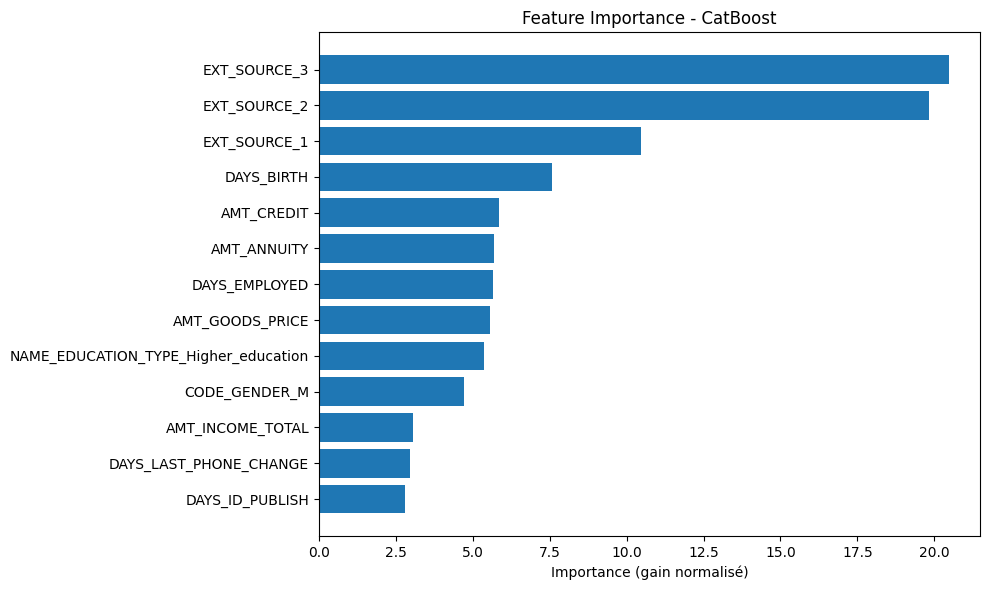

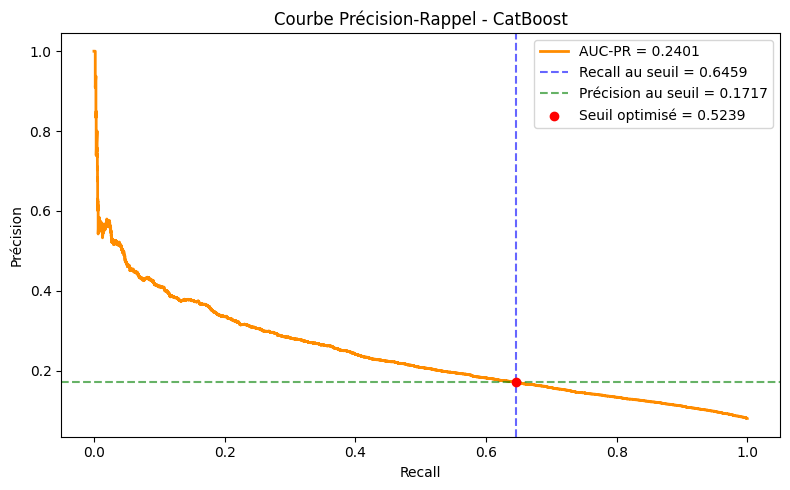

c:\Users\chris\Initiez_vous_au_ML_Ops\venv312\Lib\site-packages\mlflow\types\utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(
2026/05/09 17:44:11 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/09 17:44:25 INFO mlflow.models.model: Found the following environment variables used during model inference: 

<ModelVersion: aliases=[], creation_timestamp=1778341465997, current_stage='None', deployment_job_state=None, description=None, last_updated_timestamp=1778341465997, metrics=[<Metric: dataset_digest=None, dataset_name=None, key='auc_pr_cat_opt', model_id='m-120dfd11a60b45e497014cddec5f2246', run_id='598afba2df3c4e17ae29aa77843e5ef8', step=0, timestamp=1778341447924, value=0.24011523609948246>,
 <Metric: dataset_digest=None, dataset_name=None, key='cost_val_cat_opt', model_id='m-120dfd11a60b45e497014cddec5f2246', run_id='598afba2df3c4e17ae29aa77843e5ef8', step=0, timestamp=1778341447943, value=33048.0>,
 <Metric: dataset_digest=None, dataset_name=None, key='fn_val_cat_opt', model_id='m-120dfd11a60b45e497014cddec5f2246', run_id='598afba2df3c4e17ae29aa77843e5ef8', step=0, timestamp=1778341447930, value=1758.0>,
 <Metric: dataset_digest=None, dataset_name=None, key='fp_val_cat_opt', model_id='m-120dfd11a60b45e497014cddec5f2246', run_id='598afba2df3c4e17ae29aa77843e5ef8', step=0, timestamp=

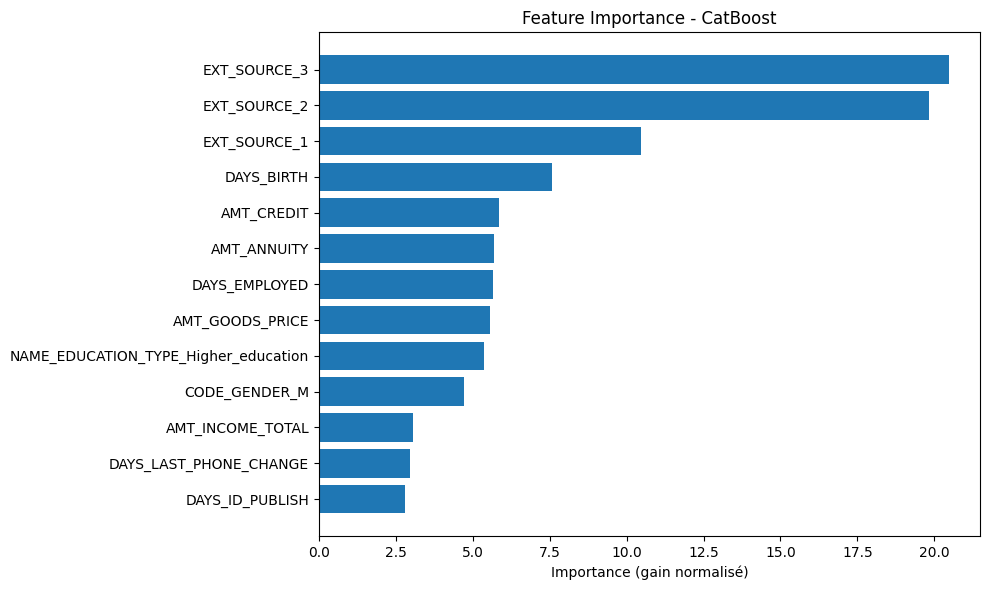

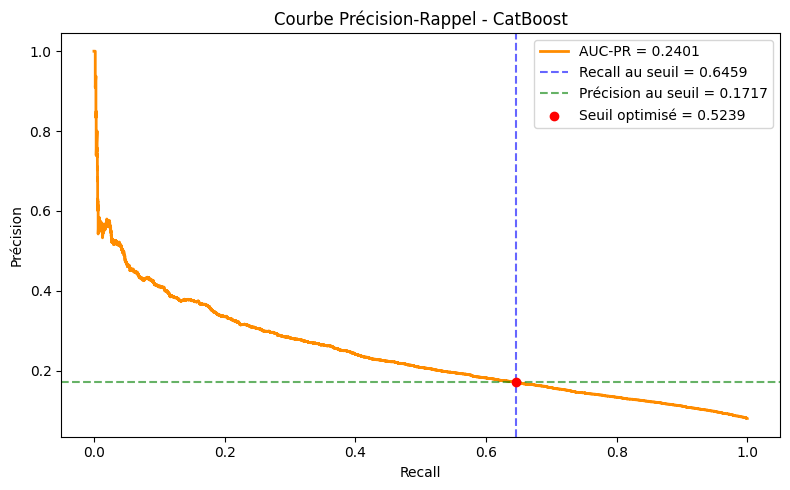

In [23]:
# Sélection de features principales pour l'API de scoring (exemple avec 13 features)

features_for_api_scoring = [
    "AMT_CREDIT",
    "AMT_INCOME_TOTAL",  
    "DAYS_BIRTH",
    "DAYS_EMPLOYED",
    "EXT_SOURCE_1",
    "EXT_SOURCE_2",
    "EXT_SOURCE_3",
    "AMT_ANNUITY",
    "AMT_GOODS_PRICE",
    "DAYS_ID_PUBLISH",
    "DAYS_LAST_PHONE_CHANGE",
    "CODE_GENDER_M",
    "NAME_EDUCATION_TYPE_Higher_education"
]

# filtre sur ces features pour les datasets d'entraînement et de validation

X_train_api = X_train[features_for_api_scoring]
X_val_api   = X_val[features_for_api_scoring]


def objective_cat(trial):

    params = {
        "loss_function": "Logloss",
        "eval_metric": "AUC",
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2),
        "depth": trial.suggest_int("depth", 3, 10),
        "min_data_in_leaf": trial.suggest_int("min_data_in_leaf", 5, 20),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bylevel": trial.suggest_float("colsample_bylevel", 0.6, 1.0),
        "auto_class_weights": trial.suggest_categorical("auto_class_weights", ["Balanced", "SqrtBalanced"]),
        "iterations": 50,
        "verbose": 0,
    }

    model = CatBoostClassifier(**params)

    y_proba = cross_val_predict(
        model, X_train_api, y_train,
        cv=skf,
        method="predict_proba",
    )[:, 1]

    roc_auc = roc_auc_score(y_train, y_proba)

    
    y_pred_default = (y_proba > 0.5).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_train, y_pred_default).ravel()
    cost = fn * 10 + fp * 1
    score = roc_auc - (cost / len(y_train))

    return score


study_cat = optuna.create_study(direction="maximize")
study_cat.optimize(objective_cat, n_trials=20)

best_params_cat = study_cat.best_params

# Modèle avec les meilleurs hyperparamètres
model_best_cat = CatBoostClassifier(**best_params_cat, iterations=50,verbose=0)

# TunedThresholdClassifierCV optimise le seuil via CV 
# Scorer métier 
def cost_scorer(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    cost = fn * 10 + fp * 1
    return -cost  # on maximise donc on minimise le coût -

scorer_metier = make_scorer(cost_scorer)

tuned_cat = TunedThresholdClassifierCV(
    estimator=model_best_cat,
    scoring=scorer_metier,     # optimise le coût métier
    cv=skf,                   
    refit=True                 # réentraîne sur tout X_train avec le seuil trouvé
)

tuned_cat.fit(X_train_api, y_train)
fitted_cat_model = tuned_cat.estimator_

# Seuil trouvé automatiquement
best_threshold_cat = tuned_cat.best_threshold_
print(f"Seuil optimal trouvé : {best_threshold_cat:.4f}")

# Prédictions et métriques sur X_val 
y_val_proba_cat = tuned_cat.predict_proba(X_val_api)[:, 1]
y_val_pred_cat = tuned_cat.predict(X_val_api) # on appkique le seuil optimal

roc_auc_cat_opt = roc_auc_score(y_val, y_val_proba_cat)

tn_val_cat_opt , fp_val_cat_opt, fn_val_cat_opt , tp_val_cat_opt  = confusion_matrix(y_val, y_val_pred_cat).ravel()
cost_val_cat_opt  = fn_val_cat_opt  * 10 + fp_val_cat_opt  * 1
score_val_cat_opt  = roc_auc_cat_opt  - (cost_val_cat_opt  / len(y_val))

# Précision / Recall au seuil optimisé
precision_cat_opt = precision_score(y_val, y_val_pred_cat)
recall_cat_opt    = recall_score(y_val, y_val_pred_cat)

# Courbe Précision-Rappel + AUC-PR
precisions, recalls, _ = precision_recall_curve(y_val, y_val_proba_cat)
auc_pr_cat_opt = auc(recalls, precisions)

print(f"  ROC-AUC_cat_opt               : {roc_auc_cat_opt:.4f}")
print(f"  auc_pr_cat_opt               : {auc_pr_cat_opt:.4f}")
print(f"  Seuil optimisé_cat_opt        : {best_threshold_cat:.4f}")
print(f"  Précision_cat_opt             : {precision_cat_opt:.4f}")
print(f"  Recall_cat_opt               : {recall_cat_opt:.4f}")
print(f"  Faux Négatifs (fn)_cat_opt    : {fn_val_cat_opt}  (coût x10 → {fn_val_cat_opt * 10})")
print(f"  Faux Positifs (fp)_cat_opt    : {fp_val_cat_opt}  (coût x1  → {fp_val_cat_opt * 1})")
print(f"  Coût métier total_cat_opt     : {cost_val_cat_opt}")
print(f"  Score Optuna (val)_cat_opt    : {score_val_cat_opt:.4f}")


# Feature Importance CatBoost
feature_importance = tuned_cat.estimator_.get_feature_importance()
sorted_idx = feature_importance.argsort()[::-1]
sorted_importance = feature_importance[sorted_idx]
sorted_names = [features_for_api_scoring[i] for i in sorted_idx]

# Plot
plt.figure(figsize=(10, 6))
plt.barh(sorted_names[:20][::-1], sorted_importance[:20][::-1])
plt.xlabel("Importance (gain normalisé)")
plt.title("Feature Importance - CatBoost")
plt.tight_layout()
plt.show()

# Courbe Précision-Rappel

plt.figure(figsize=(8, 5))
plt.plot(recalls, precisions, color="darkorange", lw=2,
         label=f"AUC-PR = {auc_pr_cat_opt:.4f}")
plt.axvline(x=recall_cat_opt, color="blue", linestyle="--", alpha=0.6,
            label=f"Recall au seuil = {recall_cat_opt:.4f}")
plt.axhline(y=precision_cat_opt, color="green", linestyle="--", alpha=0.6,
            label=f"Précision au seuil = {precision_cat_opt:.4f}")
plt.scatter([recall_cat_opt], [precision_cat_opt], color="red", zorder=5,
            label=f"Seuil optimisé = {best_threshold_cat:.4f}")
plt.xlabel("Recall")
plt.ylabel("Précision")
plt.title("Courbe Précision-Rappel - CatBoost")
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()

with mlflow.start_run(run_name="CatBoost_Optuna_TunedThreshold") as run:

    mlflow.log_params(best_params_cat)
    mlflow.log_param("optimized_threshold", best_threshold_cat)
    mlflow.log_param("features_for_api_scoring", features_for_api_scoring)  # ← traçabilité

    mlflow.log_metric("roc_auc_cat_opt", roc_auc_cat_opt)
    mlflow.log_metric("auc_pr_cat_opt", auc_pr_cat_opt)
    mlflow.log_metric("precision_cat_opt", precision_cat_opt)
    mlflow.log_metric("recall_cat_opt", recall_cat_opt)
    mlflow.log_metric("fn_val_cat_opt", fn_val_cat_opt)
    mlflow.log_metric("fp_val_cat_opt", fp_val_cat_opt)
    mlflow.log_metric("cost_val_cat_opt", cost_val_cat_opt)
    mlflow.log_metric("score_val_cat_opt", score_val_cat_opt)

    # inférer la signature depuis X_train_api
    signature = infer_signature(X_train_api, tuned_cat.predict_proba(X_val_api)[:, 1])

    # On logue le wrapper complet
    mlflow.sklearn.log_model(tuned_cat,
        "model",
        signature=signature,
        input_example=X_val_api.iloc[:13]   # 13 lignes d'exemple pour FastAPI
    )
    
    # Feature importance figure
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(sorted_names[:20][::-1], sorted_importance[:20][::-1])
    ax.set_xlabel("Importance (gain normalisé)")
    ax.set_title("Feature Importance - CatBoost")
    plt.tight_layout()
    mlflow.log_figure(fig, "feature_importance.png")

    # Courbe PR figure
    fig_pr, ax2 = plt.subplots(figsize=(8, 5))
    ax2.plot(recalls, precisions, color="darkorange", lw=2,
             label=f"AUC-PR = {auc_pr_cat_opt:.4f}")
    ax2.axvline(x=recall_cat_opt, color="blue", linestyle="--", alpha=0.6,
                label=f"Recall au seuil = {recall_cat_opt:.4f}")
    ax2.axhline(y=precision_cat_opt, color="green", linestyle="--", alpha=0.6,
                label=f"Précision au seuil = {precision_cat_opt:.4f}")
    ax2.scatter([recall_cat_opt], [precision_cat_opt], color="red", zorder=5,
                label=f"Seuil optimisé = {best_threshold_cat:.4f}")
    ax2.set_xlabel("Recall")
    ax2.set_ylabel("Précision")
    ax2.set_title("Courbe Précision-Rappel - CatBoost")
    ax2.legend(loc="upper right")
    plt.tight_layout()
    mlflow.log_figure(fig_pr, "precision_recall_curve.png")

    # Récupération automatique du run_id
    run_id = run.info.run_id

# Register
mlflow.register_model(
    f"runs:/{run_id}/model",
    "CatBoost_Optuna_TunedThreshold_ready_for_api_scoring"
)

In [24]:
print(type(model_best_cat))
print(type(tuned_cat))  # ou le nom de votre wrapper

<class 'catboost.core.CatBoostClassifier'>
<class 'sklearn.model_selection._classification_threshold.TunedThresholdClassifierCV'>


In [25]:
print(model_best_cat.is_fitted())  # doit retourner True

False


# Explainer SHAP pour CatBoost

In [26]:
explainer = shap.TreeExplainer(fitted_cat_model)
shap_values = explainer(X_val)


# BEESWARM — influence globale de chaque feature

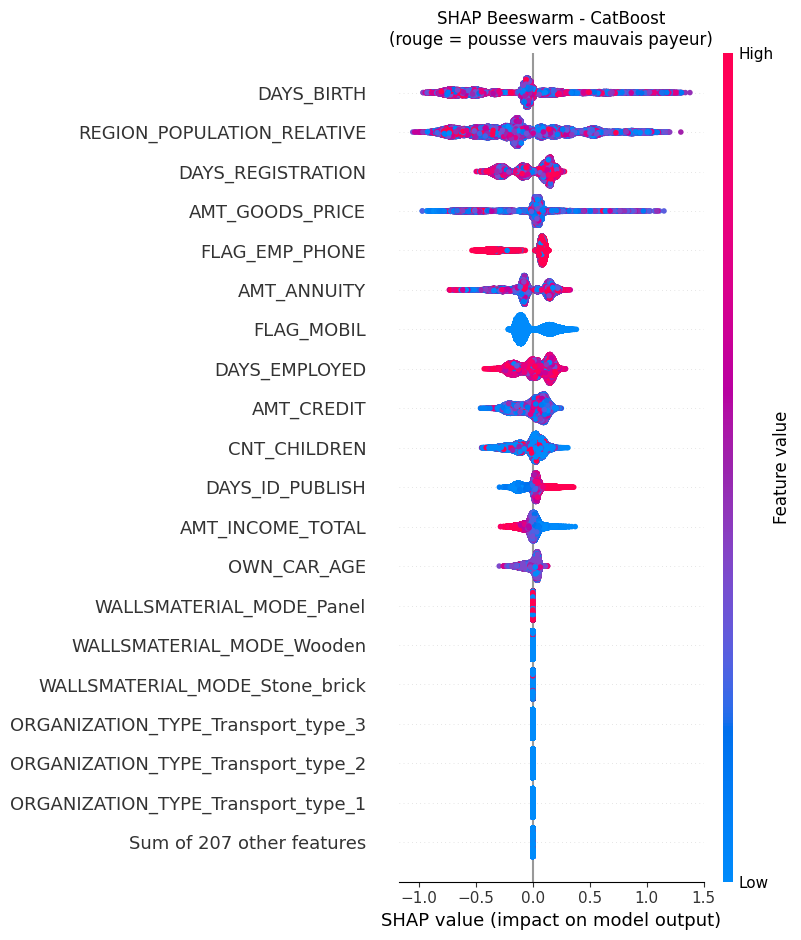

In [27]:
# quelles features pour "mauvais payeur" (valeur SHAP positive = risque +)

plt.figure()
shap.plots.beeswarm(shap_values, max_display=20, show=False)
plt.title("SHAP Beeswarm - CatBoost\n(rouge = pousse vers mauvais payeur)")
plt.tight_layout()
plt.show()


# WATERFALL — explication d'un individu précis

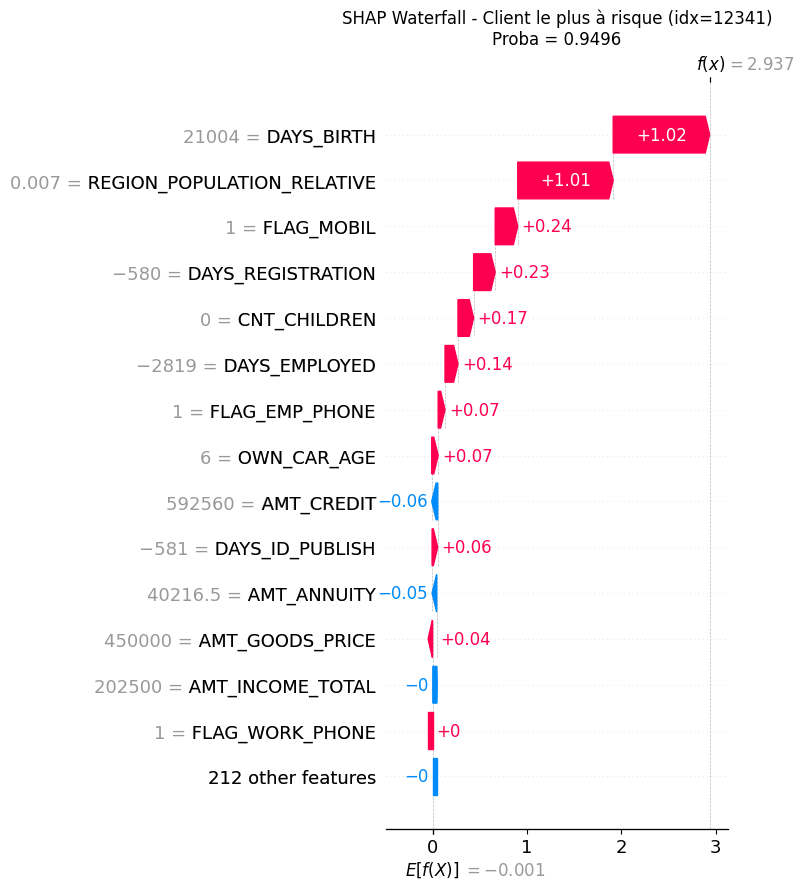

In [28]:
# Exemple : le client avec la proba la plus élevée (le plus à risque d'être mauvais payeur)

idx_most_risky = y_val_proba_cat.argmax()

plt.figure()
shap.plots.waterfall(shap_values[idx_most_risky], max_display=15, show=False)
plt.title(f"SHAP Waterfall - Client le plus à risque (idx={idx_most_risky})\nProba = {y_val_proba_cat[idx_most_risky]:.4f}")
plt.tight_layout()
plt.show()

# Waterfall sur un faux négatif (mauvais payeur non détecté: ce qui est le plus cher)

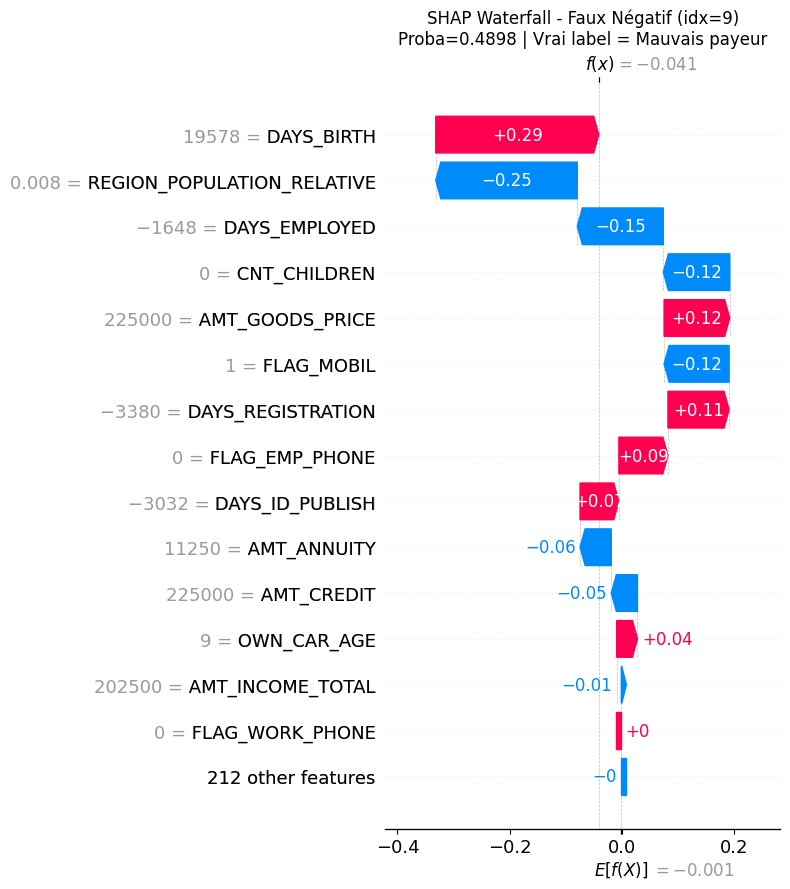

In [29]:
fn_indices = np.where((y_val == 1) & (y_val_pred_cat == 0))[0]
if len(fn_indices) > 0:
    idx_fn = fn_indices[0]
    plt.figure()
    shap.plots.waterfall(shap_values[idx_fn], max_display=15, show=False)
    plt.title(f"SHAP Waterfall - Faux Négatif (idx={idx_fn})\nProba={y_val_proba_cat[idx_fn]:.4f} | Vrai label = Mauvais payeur")
    plt.tight_layout()
    plt.show()


# Log MLflow

In [30]:
with mlflow.start_run(run_name="CatBoost_SHAP_Analysis"):

    # Beeswarm
    fig_bee, _ = plt.subplots()
    shap.plots.beeswarm(shap_values, max_display=20, show=False)
    plt.title("SHAP Beeswarm - CatBoost")
    plt.tight_layout()
    mlflow.log_figure(fig_bee, "shap_beeswarm.png")

    # Waterfall client le plus risqué
    fig_wf, _ = plt.subplots()
    shap.plots.waterfall(shap_values[idx_most_risky], max_display=15, show=False)
    plt.title(f"SHAP Waterfall - Client le plus à risque")
    plt.tight_layout()
    mlflow.log_figure(fig_wf, "shap_waterfall_most_risky.png")

    # Waterfall faux négatif
    if len(fn_indices) > 0:
        fig_fn, _ = plt.subplots()
        shap.plots.waterfall(shap_values[idx_fn], max_display=15, show=False)
        plt.title(f"SHAP Waterfall - Faux Négatif")
        plt.tight_layout()
        mlflow.log_figure(fig_fn, "shap_waterfall_false_negative.png")